In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Upload the cleaned dataset
from google.colab import files

uploaded = files.upload()

Saving student_performance_clean.csv to student_performance_clean.csv


In [ ]:
# Load the uploaded CSV file into a DataFrame
df = pd.read_csv(next(iter(uploaded)))

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# Display the first 5 rows of the dataset
df.head()

,Student_ID,Hours_Studied,Attendance,Previous_Score,Assignments_Completed,Sleep_Hours,Final_Marks,Result
0,STU001,0.8,96.3,85.5,8,4.1,59.0,Pass
1,STU002,7.8,68.2,45.7,3,4.1,56.3,Pass
2,STU003,4.4,40.3,63.4,6,4.1,52.2,Pass
3,STU004,7.2,100.0,66.1,6,5.3,64.1,Pass
4,STU005,9.8,42.9,88.6,9,7.0,77.4,Pass


In [ ]:
# Check the shape of the dataset
print("Shape:", df.shape)

# Check the column names
print("\nColumns:")
print(df.columns)

# Check the data types of each column
print("\nData Types:")
print(df.dtypes)

Shape: (300, 8)

Columns:
Index(['Student_ID', 'Hours_Studied', 'Attendance', 'Previous_Score',
       'Assignments_Completed', 'Sleep_Hours', 'Final_Marks', 'Result'],
      dtype='object')

Data Types:
Student_ID                object
Hours_Studied            float64
Attendance               float64
Previous_Score           float64
Assignments_Completed      int64
Sleep_Hours              float64
Final_Marks              float64
Result                    object
dtype: object


In [ ]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Student_ID               0
Hours_Studied            0
Attendance               0
Previous_Score           0
Assignments_Completed    0
Sleep_Hours              0
Final_Marks              0
Result                   0
dtype: int64

Duplicate rows:
0


In [ ]:
# Check the distribution of Pass and Fail
result_counts = df["Result"].value_counts()

print(result_counts)

Result
Pass    249
Fail     51
Name: count, dtype: int64


In [ ]:
# Calculate the percentage of Pass and Fail students
result_percentage = df["Result"].value_counts(normalize=True) * 100

print(result_percentage)

Result
Pass    83.0
Fail    17.0
Name: proportion, dtype: float64


In [ ]:
# Compare average values of numerical features for Pass and Fail
average_values = df.groupby("Result").mean(numeric_only=True)

print(average_values)

        Hours_Studied  Attendance  Previous_Score  Assignments_Completed  \
Result                                                                     
Fail         1.929412   63.635294       55.492157               3.549020   
Pass         5.494779   71.467470       66.621285               5.365462   

        Sleep_Hours  Final_Marks  
Result                            
Fail       6.068627    38.358824  
Pass       6.562651    62.980321  


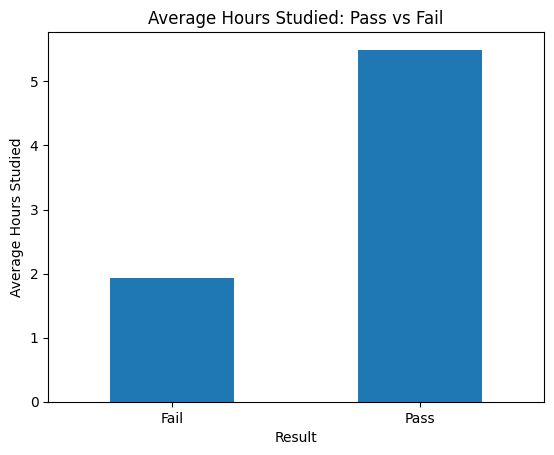

In [ ]:
# Compare average Hours_Studied for Pass and Fail students
hours_by_result = df.groupby("Result")["Hours_Studied"].mean()

hours_by_result.plot(kind="bar")

plt.title("Average Hours Studied: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Average Hours Studied")
plt.xticks(rotation=0)
plt.show()

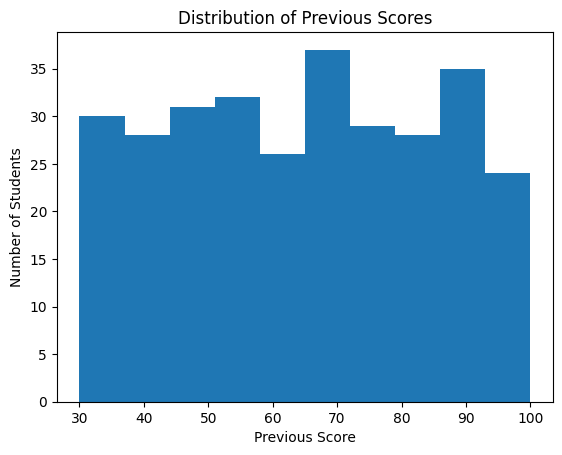

In [ ]:
# Create a histogram for Previous_Score
plt.hist(df["Previous_Score"], bins=10)

plt.title("Distribution of Previous Scores")
plt.xlabel("Previous Score")
plt.ylabel("Number of Students")
plt.show()

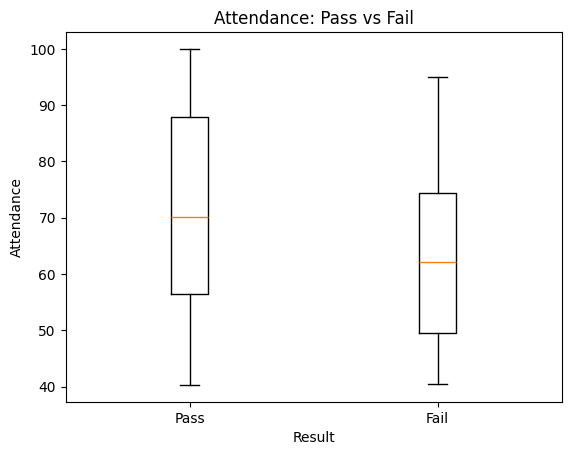

In [ ]:
# Compare Attendance for Pass and Fail students using a boxplot

pass_attendance = df[df["Result"] == "Pass"]["Attendance"]
fail_attendance = df[df["Result"] == "Fail"]["Attendance"]

plt.boxplot(
    [pass_attendance, fail_attendance],
    tick_labels=["Pass", "Fail"]
)

plt.title("Attendance: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance")
plt.show()

In [ ]:
# Convert Result into numerical values
df["Result_num"] = df["Result"].map({
    "Pass": 1,
    "Fail": 0
})

# Check the conversion
df[["Result", "Result_num"]].head()

,Result,Result_num
0,Pass,1
1,Pass,1
2,Pass,1
3,Pass,1
4,Pass,1


In [ ]:
# Calculate correlation of numerical columns with Result_num
correlation = df.select_dtypes(include=np.number).corr()["Result_num"].sort_values(ascending=False)

print(correlation)

Result_num               1.000000
Final_Marks              0.654639
Hours_Studied            0.461345
Assignments_Completed    0.213361
Previous_Score           0.211080
Attendance               0.166643
Sleep_Hours              0.126364
Name: Result_num, dtype: float64


In [ ]:
# Find the feature with the strongest correlation with Result_num
feature_correlations = correlation.drop("Result_num")

strongest_feature = feature_correlations.abs().idxmax()
strongest_value = feature_correlations[strongest_feature]

print("Strongest correlated feature:", strongest_feature)
print("Correlation:", strongest_value)

Strongest correlated feature: Final_Marks
Correlation: 0.6546392137647667


## EDA Observations

1. The dataset contains both Pass and Fail students, showing the distribution of student results.

2. Pass and Fail students show differences in their average study-related features such as Hours_Studied, Attendance, and Previous_Score.

3. Final_Marks has the strongest positive correlation with Result_num, with a correlation of approximately 0.655, indicating a moderate positive relationship with the result.


In [ ]:
# Save the updated DataFrame
df.to_csv("student_performance_eda.csv", index=False)

print("Updated EDA dataset saved successfully!")

Updated EDA dataset saved successfully!


In [ ]:
from google.colab import files

files.download("student_performance_eda.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>